In [59]:
from typing import List
from copy import deepcopy
import itertools
import functools
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import cirq
from encoded.repetition_code import (
    generate_stabilizers,
    encoding_repetition
)
from encoded.expanded_repetition_code import (
    x_bar,
    z_bar,
    stabilizer_generators,
    encoding_expanded_repetition,
    U_XXX
)
from encoded.symmetry_expansion import symmetry_expansion

In [49]:
def generate_stabilizer_elements(generators: List[cirq.PauliString]) -> List[cirq.PauliString]:
    elements = []
    for string in itertools.chain.from_iterable(itertools.combinations(generators, r) for r in range(len(generators) + 1)):
        elements.append(
            functools.reduce(lambda a, b: a * b, string, cirq.PauliString())
        )
    return elements

In [50]:
qubits = cirq.LineQubit.range(3)
n = 3
repetition_generators = []
for i in range(n-1):
    repetition_generators.append(cirq.Z.on(qubits[i]) * cirq.Z.on(qubits[i+1]))
repetition_elements = generate_stabilizer_elements(repetition_generators)
print(f"The group contains {len(repetition_elements)} elements:")
for element in repetition_elements:
    print(element)
repetition_qubits = deepcopy(qubits)

The group contains 4 elements:
I
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
Z(q(0))*Z(q(2))


In [51]:
def repetition_prep_circuit(psi_ckt: cirq.Circuit) -> cirq.Circuit:
    ckt = cirq.Circuit()
    ckt += psi_ckt
    ckt.append(cirq.CNOT(repetition_qubits[0], repetition_qubits[1]))
    ckt.append(cirq.CNOT(repetition_qubits[1], repetition_qubits[2]))
    return ckt

In [52]:
repetition_logical_z = cirq.Z.on(qubits[0])
repetition_logical_x = cirq.X.on(qubits[0]) * cirq.X.on(qubits[1]) * cirq.X.on(qubits[2])

In [53]:
qubits = cirq.LineQubit.range(4)
n = len(qubits)
extended_generators = stabilizer_generators
print(f"The group has {len(extended_generators)} generators:")
for generator in extended_generators:
    print(generator)
extended_elements = generate_stabilizer_elements(extended_generators)
print(f"The group contains {len(extended_elements)} elements:")
for element in extended_elements:
    print(element)
extended_qubits = deepcopy(qubits)

The group has 3 generators:
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
X(q(0))*X(q(1))*X(q(2))*X(q(3))
The group contains 8 elements:
I
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
X(q(0))*X(q(1))*X(q(2))*X(q(3))
Z(q(0))*Z(q(2))
-Y(q(0))*Y(q(1))*X(q(2))*X(q(3))
-X(q(0))*Y(q(1))*Y(q(2))*X(q(3))
-Y(q(0))*X(q(1))*Y(q(2))*X(q(3))


In [60]:
def extended_prep_circuit(psi_ckt: cirq.Circuit) -> cirq.Circuit:
    ckt = cirq.Circuit()
    ckt += psi_ckt
    ckt.append(cirq.CNOT(extended_qubits[0], extended_qubits[1]))
    ckt.append(cirq.CNOT(extended_qubits[1], extended_qubits[2]))
    ckt += U_XXX
    return ckt

In [54]:
# Prepare an even superposition of the |0> and |+> states.
q = qubits[0]
psi_prep_ckt = cirq.Circuit()
psi_prep_ckt.append(cirq.H(q))
psi_prep_ckt.append(cirq.Ry(rads=-np.pi/4).on(q))
print(psi_prep_ckt)
sim = cirq.Simulator()
result = sim.simulate(psi_prep_ckt)
psi = result.final_state_vector

plus_state = np.array([1., 1.]) / np.sqrt(2.)
zero_state = np.array([1., 0.])
target_state = plus_state + zero_state
target_state /= la.norm(target_state)
print(la.norm(target_state - psi))

0: ───H───Ry(-0.25π)───
4.5816625160956935e-08


In [55]:
exact_observable = cirq.PauliSum.from_pauli_strings([cirq.X.on(q)])
exact_expectation_value = exact_observable.expectation_from_state_vector(psi, {q: 0})
print(f"Exact expectation: {exact_expectation_value}")

Exact expectation: (0.7071067094802856+0j)


In [56]:
def run_repetition_code(noise_rate: float, noise_gate: cirq.Gate) -> float:
    """Get the error in the expectation value of logical X for a repetition code
    using subspace expansion."""

    circuit = cirq.Circuit()
    circuit += repetition_prep_circuit(psi_prep_ckt)
    for q in repetition_qubits:
        circuit.append(noise_gate(p=noise_rate).on(q))
    sim = cirq.DensityMatrixSimulator()
    mitigated_exp_val = symmetry_expansion(circuit, repetition_logical_x, repetition_elements, sim=sim)
    return abs(exact_expectation_value - mitigated_exp_val)

In [61]:
def run_extended_code(noise_rate: float, ancilla_noise_rate: float, noise_gate: cirq.Gate) -> float:
    """Get the error in the expectation value of logical X for a repetition code
    using subspace expansion."""

    circuit = cirq.Circuit()
    circuit += extended_prep_circuit(psi_prep_ckt)
    for i, q in enumerate(repetition_qubits):
        if i != 3:
            circuit.append(noise_gate(p=noise_rate).on(q))
        else:
            circuit.append(noise_gate(p=ancilla_noise_rate).on(q))
    sim = cirq.DensityMatrixSimulator()
    mitigated_exp_val = symmetry_expansion(circuit, x_bar, extended_elements, sim=sim)
    return abs(exact_expectation_value - mitigated_exp_val)

In [63]:
noise_rates = np.linspace(1e-4, 1e-2, num=10)
repetition_errs = []
extended_errs = []
for noise_rate in noise_rates:
    err = run_repetition_code(noise_rate, cirq.BitFlipChannel)
    repetition_errs.append(err)
    err = run_extended_code(noise_rate, 1e-4, cirq.BitFlipChannel)
    extended_errs.append(err)

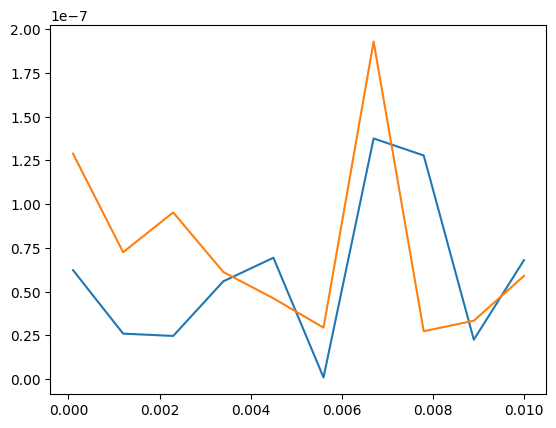

In [64]:
fig, ax = plt.subplots()
ax.plot(noise_rates, repetition_errs, label="Repetition")
ax.plot(noise_rates, extended_errs, label="Extended")